In [1]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv(r"C:\Users\ASUS\OneDrive\Videos\Code Alpha Internship\Project 2\data\heart_cleveland_upload.csv") 
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,condition
0,69,1,0,160,234,1,2,131,0,0.1,1,1,0,0
1,69,0,0,140,239,0,0,151,0,1.8,0,2,0,0
2,66,0,0,150,226,0,0,114,0,2.6,2,0,0,0
3,65,1,0,138,282,1,2,174,0,1.4,1,1,0,1
4,64,1,0,110,211,0,2,144,1,1.8,1,0,0,0


In [4]:
df_backup=df.copy()

### 1. Understanding of Data

In [3]:
df.isnull().sum()

age          0
sex          0
cp           0
trestbps     0
chol         0
fbs          0
restecg      0
thalach      0
exang        0
oldpeak      0
slope        0
ca           0
thal         0
condition    0
dtype: int64

In [5]:
df.shape

(297, 14)

In [6]:
df.columns

Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'condition'],
      dtype='str')

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 297 entries, 0 to 296
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   age        297 non-null    int64  
 1   sex        297 non-null    int64  
 2   cp         297 non-null    int64  
 3   trestbps   297 non-null    int64  
 4   chol       297 non-null    int64  
 5   fbs        297 non-null    int64  
 6   restecg    297 non-null    int64  
 7   thalach    297 non-null    int64  
 8   exang      297 non-null    int64  
 9   oldpeak    297 non-null    float64
 10  slope      297 non-null    int64  
 11  ca         297 non-null    int64  
 12  thal       297 non-null    int64  
 13  condition  297 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 32.6 KB


In [10]:
df['condition'].value_counts()

condition
0    160
1    137
Name: count, dtype: int64

<Axes: xlabel='condition', ylabel='count'>

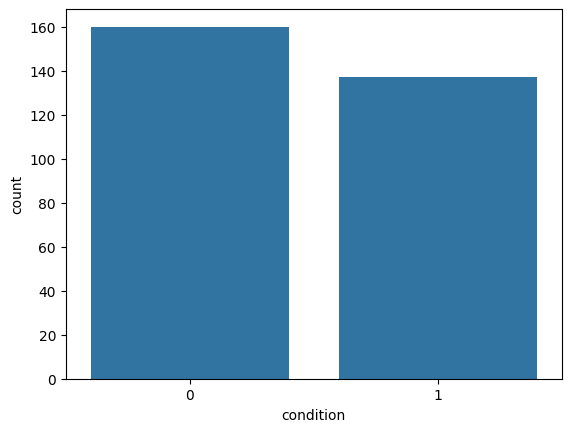

In [12]:
sns.countplot(x='condition', data=df)

In [13]:
df.describe() # statistical summary

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,condition
count,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000
mean,54.542088,0.676768,2.158249,131.693603,247.350168,0.144781,0.996633,149.599327,0.326599,1.055556,0.602694,0.676768,0.835017,0.461279
std,9.049736,0.468500,0.964859,17.762806,51.997583,0.352474,0.994914,22.941562,0.469761,1.166123,0.618187,0.938965,0.956690,0.499340
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,2.000000,120.000000,211.000000,0.000000,0.000000,133.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,56.000000,1.000000,2.000000,130.000000,243.000000,0.000000,1.000000,153.000000,0.000000,0.800000,1.000000,0.000000,0.000000,0.000000
75%,61.000000,1.000000,3.000000,140.000000,276.000000,0.000000,2.000000,166.000000,1.000000,1.600000,1.000000,1.000000,2.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,3.000000,2.000000,1.000000


### 2. Univariate Analysis

<Axes: xlabel='age', ylabel='Count'>

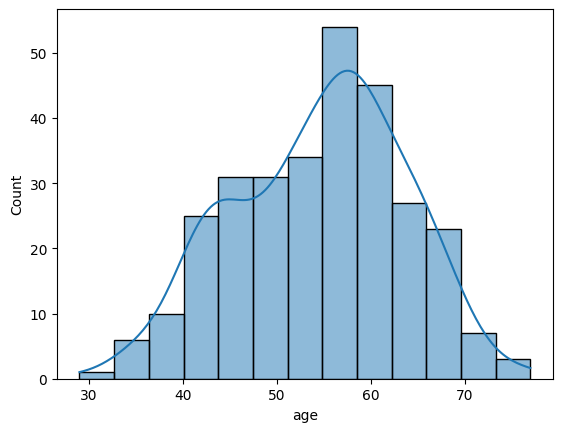

In [18]:
sns.histplot(df['age'], kde=True)

#### The distribution of age is approximately normal (bell-shaped) with a slight left skew. Most patients fall in the age range of 50 to 65 years, with a peak around 55–60, indicating that heart disease cases are more common in middle-aged to older individuals.

#### This suggests that age is likely an important factor in predicting heart disease.

### 3. Categorical Analysis

In [20]:
df['cp'].value_counts()

cp
3    142
2     83
1     49
0     23
Name: count, dtype: int64

<Axes: xlabel='cp', ylabel='count'>

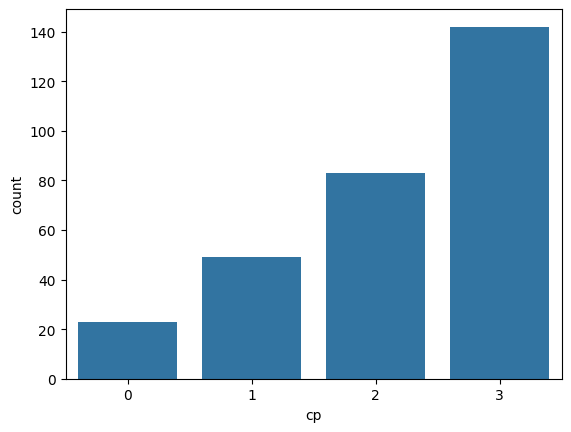

In [21]:
sns.countplot(x=df['cp'], data=df)

#### Most Patient have type 3 chest pain which is asymptomatic, followed by non-anginal pain (type 2), followed by atypical angina (type 1), and last and least typical angina (type 0)

<Axes: xlabel='fbs', ylabel='count'>

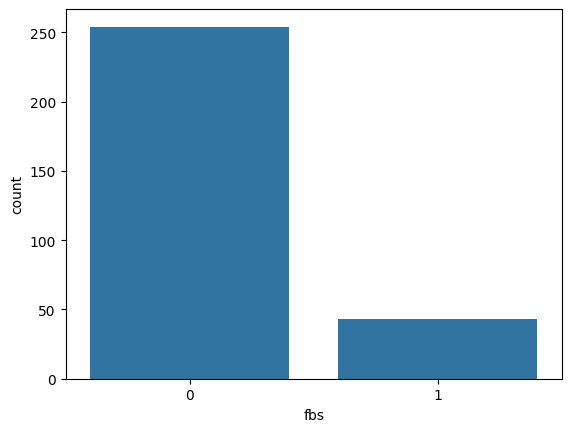

In [24]:
sns.countplot(x=df['fbs'], data=df)

####  Here, fbs stands for fasting blood sugar and if it is 0 than fasting blood sugar is less than 120 mg/dl, otherwise greater than 120 mg/dl and it is observed that most people have fbs less than 120 mg/dl.

<Axes: xlabel='restecg', ylabel='count'>

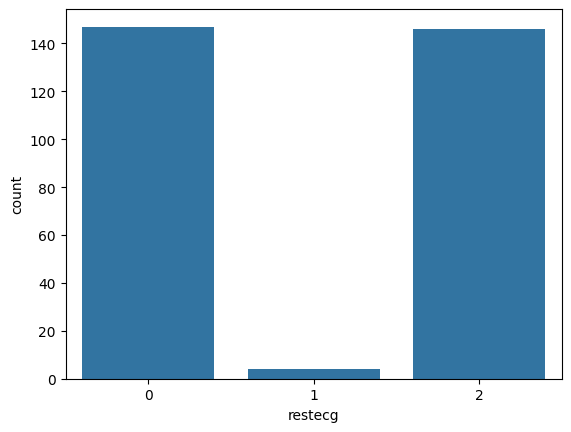

In [25]:
sns.countplot(x=df['restecg'], data=df)

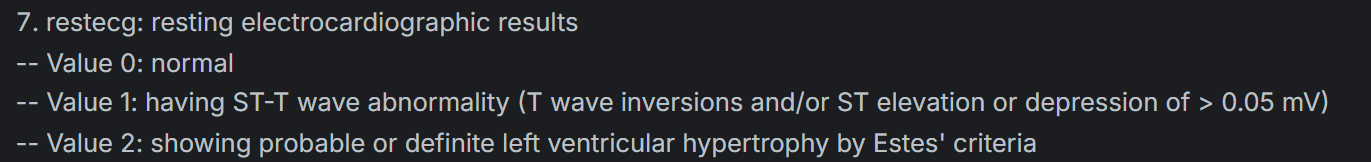

#### Categories 0 and 1 are most frequent

### Bivariate Analysis

<Axes: xlabel='condition', ylabel='age'>

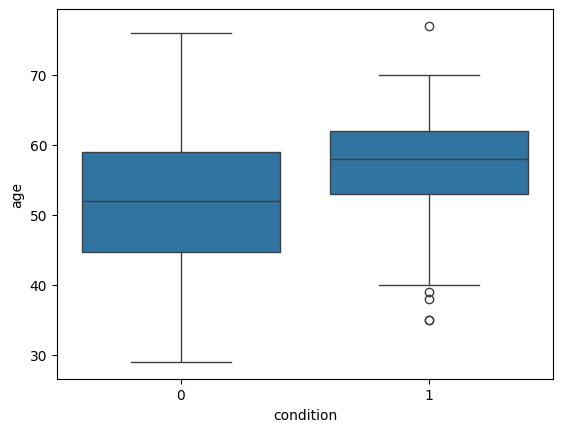

In [28]:
sns.boxplot(x=df['condition'], y=df['age'], data=df)

### Age vs Disease Condition

#### Patients with heart disease (condition = 1) tend to be older compared to those without the disease. The median age for diseased patients is higher, indicating a positive relationship between age and heart disease risk. This suggests that age is a significant factor in predicting heart disease.

<Axes: xlabel='condition', ylabel='chol'>

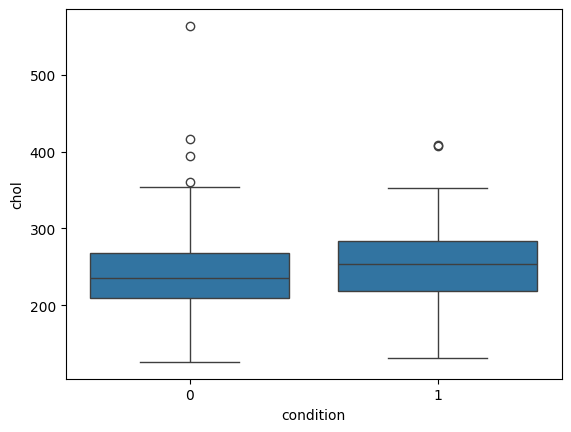

In [30]:
sns.boxplot(x='condition', y='chol', data=df)

### Cholesterol vs Disease Condition

#### Patients with heart disease generally have slightly higher cholesterol levels compared to those without the disease. However, there is significant overlap between the two groups, indicating that cholesterol alone is not a strong predictor and should be used in combination with other features.

<Axes: >

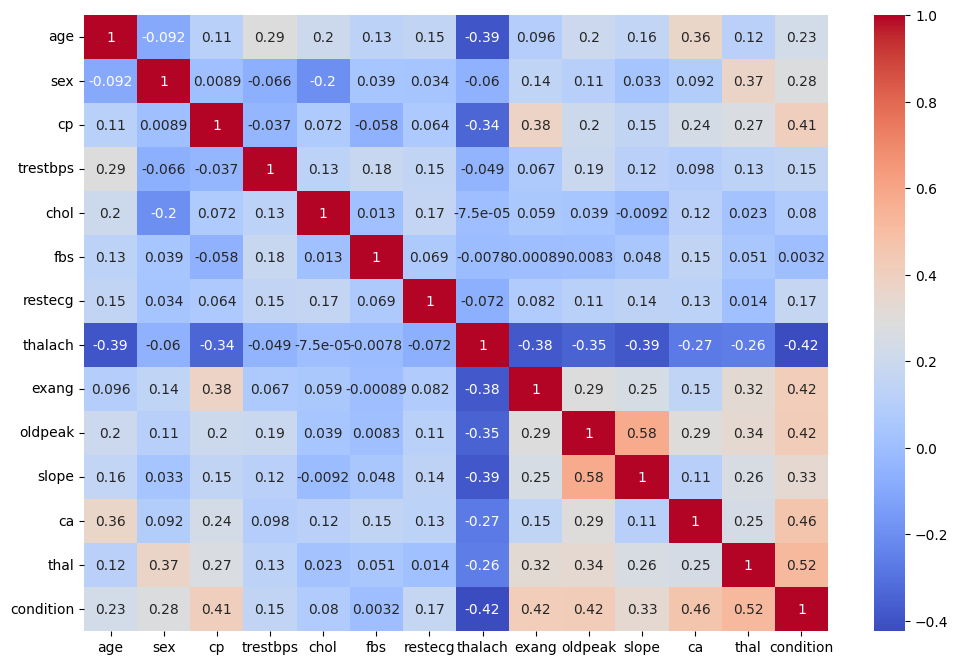

In [32]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')

### The correlation analysis shows no strong multicollinearity among features, though moderate correlation exists between some variables. Features such as thal, ca, cp, exang, and oldpeak show moderate to strong positive correlation with the target, while thalach shows a significant negative correlation. Features like chol and fbs have weak correlation with the target.

<Axes: ylabel='chol'>

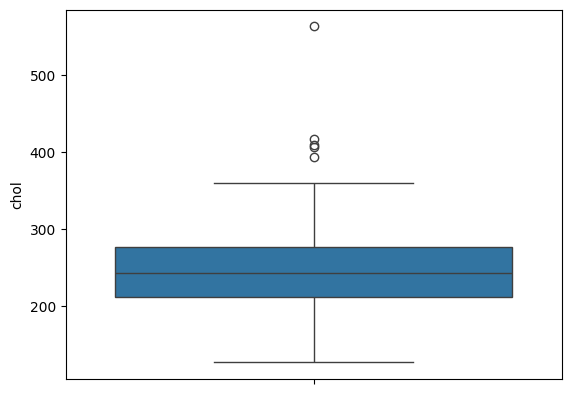

In [33]:
sns.boxplot(df['chol'])

In [38]:
df[df['chol']>370]

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,condition
79,67,0,2,115,564,0,2,160,0,1.6,1,0,2,0
83,65,0,2,140,417,1,2,157,0,0.8,0,1,0,0
180,63,0,3,150,407,0,2,154,0,4.0,1,3,2,1
188,62,0,3,140,394,0,2,157,0,1.2,1,0,0,0
238,56,0,3,134,409,0,2,150,1,1.9,1,2,2,1


### Outlier Handling (Cholesterol)

#### Outliers are present in the cholesterol feature. However, since this is medical data, extreme values may represent real patient conditions rather than errors. Therefore, outliers are not removed. Additionally, tree-based models like Random Forest are robust to outliers, so keeping them preserves important information.